# Turkey Earthquake Catalog — Data Quality Audit

Source: AFAD event catalog, 2011–2026, UTC
481,591 records, 9 columns

This notebook documents every data quality issue found, with counts.
No cleaning happens here — see `02_clean.ipynb`.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/afad_2011_2026.csv")

In [3]:
print(df.head())

                  Date  Longitude  Latitude  Depth   Rms Type  Magnitude  \
0  19/09/2026 20:24:25   39.21700  38.45767   7.12  0.30   ML        2.6   
1  19/09/2026 20:12:32   26.94750  38.77317   6.61  0.35   ML        2.1   
2  19/09/2026 20:00:57   26.95883  38.75217   6.80  0.40   ML        2.3   
3  19/09/2026 19:55:18   36.36167  37.97867   7.05  0.28   ML        2.1   
4  19/09/2026 19:50:34   28.13317  39.12100   6.99  0.40   ML        1.3   

                 Location  EventID  
0        Sivrice (Elazığ)   729077  
1          Aliağa (İzmir)   729075  
2          Aliağa (İzmir)   729074  
3  Göksun (Kahramanmaraş)   729072  
4    Sındırgı (Balıkesir)   729076  


In [4]:
print(df.shape)
print(df.dtypes)

(481591, 9)
Date             str
Longitude    float64
Latitude     float64
Depth        float64
Rms          float64
Type             str
Magnitude    float64
Location         str
EventID        int64
dtype: object


In [5]:
print(df["Type"].value_counts())

Type
ML        410693
Ml         55298
Md          7576
Mw          5456
MW          2560
Mwp            6
Ms(BB)         2
Name: count, dtype: int64


In [6]:
print(df.isna().sum())

Date          0
Longitude     0
Latitude      0
Depth         0
Rms           0
Type          0
Magnitude     0
Location     21
EventID       0
dtype: int64


### Issue 1 — `Date` stored as text, format is ambiguous

`df.dtypes` reports `Date` as `str`, not a datetime.
Values look like `19/09/2026 20:24:25` — day first, not month first.

Affects: all 481,591 rows.
Risk: if parsed with the wrong convention, 09/03 becomes 3 September
instead of 9 March, and nothing errors — the dates are just silently wrong.

Found with: `df.dtypes`, `df.head()`

### Issue 2 — `Type` records three system eras, not random typos

*(revised — the capitalisation is not sloppiness, it is a timestamp)*

Crosstab of year × `Type` reveals three distinct periods:

| Period | Labels used | What changed |
|---|---|---|
| 2011–2013 | `Md` + `Ml` | Duration magnitude phased out |
| **2014** | `Ml` → `ML` | Spelling changed, scale identical |
| 2014–2020 | `ML` + `Mw` | Stable |
| **2021–2023** | `Mw` → `MW` | Spelling changed again |
| 2023–2026 | `ML` + `MW` | Only two labels remain |

The `Md` → `ML` transition:

| Year | Md | Ml / ML |
|---|---|---|
| 2011 | 4,111 | 8,289 |
| 2012 | 2,721 | 24,253 |
| 2013 | 266 | 22,756 |
| 2014 | 291 | 23,142 |

**Consequence:** the first three years of the catalog use a different
magnitude scale from the remaining thirteen. A magnitude 2.5 in 2012
and a magnitude 2.5 in 2024 are not the same measurement.

Found with: `pd.crosstab(df["Date"].str[6:10], df["Type"])`
Decision: *(Phase 2)*

### Issue 3 — Inconsistent capitalization in `Type`

Same scale written two ways:
- `ML` / `Ml` → 465,991 records
- `Mw` / `MW` → 8,016 records

Found with: `df["Type"].value_counts()`

### Issue 4 — Missing values in `Location`

21 rows have no `Location` (0.004% of the data).
Every other column is complete — including `Longitude` and `Latitude`,
so these are valid events with an unwritten place name.

Found with: `df.isna().sum()`

### Checked, no issue found

- **Encoding**: Turkish characters render correctly (`Elazığ`, `Kahramanmaraş`).
  No `windows-1254` conversion needed.
- **Missing values**: only `Location` has nulls. All other 8 columns are complete.
- **Separator / decimal**: standard comma separator, period decimal.
  `read_csv` works with no extra parameters.

In [8]:
print(df.describe().T)

              count           mean            std           min          25%  \
Longitude  481591.0      32.939133       5.616929      19.71717      27.9838   
Latitude   481591.0      38.459261       1.293415      29.67600      37.6131   
Depth      481591.0       8.241475       5.896518      -0.03400       7.0000   
Rms        481591.0       0.418065       0.327952       0.00000       0.2600   
Magnitude  481591.0       1.817825       0.660352       0.00000       1.3000   
EventID    481591.0  464634.029091  169910.972521  139686.00000  343727.5000   

                   50%            75%          max  
Longitude      30.8615      37.850535      52.3036  
Latitude       38.4390      39.220600      45.9413  
Depth           7.0000       7.110000     345.2000  
Rms             0.3900       0.540000      82.8000  
Magnitude       1.7000       2.200000       7.7000  
EventID    484723.0000  608255.500000  729077.0000  


In [22]:
print((df["Depth"]==7.0).sum())
print((df["Depth"]<0).sum())
print((df["Magnitude"]==0).sum())
print((df["Rms"]>5).sum())
print((~(df["Latitude"].between(36, 42) & (df["Longitude"].between(26, 45)))).sum())

180700
4
12
48
26672


### Issue 5 — `Depth` has a default value of 7.0 km

180,700 records (**37.5%**) have a depth of exactly 7.0 km.
Real depths do not cluster on a single value — this is a placeholder
used when depth could not be determined.

Consequence: depth is unusable for more than a third of the catalog,
and it does not look missing.

Found with: `df.describe()` (25% and 50% both exactly 7.0),
then `(df["Depth"] == 7.0).sum()`
Decision: *(Phase 2)*

### Issue 6 — Negative depth values

4 records have depth below 0 (min: −0.034 km).
An earthquake above ground level is physically impossible;
these are numerical artefacts of the location solution.

Found with: `(df["Depth"] < 0).sum()`
Decision: *(Phase 2)*

### Issue 7 — Magnitude exactly 0

12 records have `Magnitude == 0`. Possible in principle for very small
events, but an exact zero is more likely a "not determined" placeholder.

Found with: `(df["Magnitude"] == 0).sum()`
Decision: *(Phase 2)*

### Issue 8 — `Rms` outliers

48 records have `Rms > 5`, against a 75th percentile of 0.54 and a max of 82.8.
`Rms` measures how well the location solution fits; these events are
poorly located and their coordinates should not be trusted.

Found with: `(df["Rms"] > 5).sum()`
Decision: *(Phase 2)*

### Issue 9 — Events outside Turkey's bounding box

26,672 records (**5.5%**) fall outside roughly 36–42°N / 26–45°E.
Not a data error: AFAD monitors the wider region, so events in Greece,
Georgia, Iran and Iraq are included deliberately.

This is a **scope** decision, not a cleaning one.

Found with: `(~(df["Latitude"].between(36,42) & df["Longitude"].between(26,45))).sum()`
Decision: *(Phase 2)*

In [23]:
print(df.duplicated().sum())
print(df["EventID"].duplicated().sum())
print(df["Location"].nunique())

0
0
76964


In [27]:
print(df["Location"].value_counts().head(20))

Location
Sındırgı (Balıkesir)            27307
Simav (Kütahya)                 12904
Tuşba (Van)                      8551
Akhisar (Manisa)                 8155
Pütürge (Malatya)                8099
Yeşilyurt (Malatya)              7871
Göksun (Kahramanmaraş)           7678
Doğanşehir (Malatya)             6653
Sivrice (Elazığ)                 5556
Menteşe (Muğla)                  5275
Ula (Muğla)                      4925
Elbistan (Kahramanmaraş)         4714
Saimbeyli (Adana)                4678
Pazarcık (Kahramanmaraş)         4521
Ayvacık (Çanakkale)              4474
Dulkadiroğlu (Kahramanmaraş)     4192
Milas (Muğla)                    3621
Çelikhan (Adıyaman)              3495
Ege Denizi                       3486
Sincik (Adıyaman)                3469
Name: count, dtype: int64


In [26]:
print(df["Location"].str.contains("km", na=False).sum())

108097


### Issue 10 — `Location` mixes two formats

76,964 unique values across 481,591 records.

108,097 records (**22%**) contain a distance annotation like
`[04.82 km]`, which makes almost every one of them a unique string:

- `Sivrice (Elazığ)` — plain, groupable
- `Ege Denizi - Çandarlı Körfezi - [04.82 km] Foça (İzmir)` — effectively unique

Any grouping by `Location` will work on the plain names and fragment
on the annotated ones.

Found with: `df["Location"].nunique()`, `.str.contains("km")`
Decision: *(Phase 2)*

In [28]:
print(df["Date"].str[6:10].value_counts().sort_index())

Date
2011    12405
2012    26977
2013    23612
2014    24122
2015    22286
2016    20537
2017    38283
2018    22896
2019    23479
2020    33827
2021    23751
2022    21004
2023    74503
2024    32573
2025    53882
2026    27454
Name: count, dtype: int64


### Issue 11 — First and last years are incomplete

The catalog starts ~17 Sep 2011 and ends 19 Sep 2026.
2011 covers ~3.5 months, 2026 covers ~8.7 months.
Neither can be compared directly against a full year.

In [29]:
pd.crosstab(df["Date"].str[6:10], df["Type"])

Type,ML,MW,Md,Ml,Ms(BB),Mw,Mwp
Date,,,,,,,
2011,5,0,4111,8289,0,0,0
2012,3,0,2721,24253,0,0,0
2013,532,0,266,22756,0,56,2
2014,23142,0,291,0,1,686,2
2015,21664,0,53,0,0,568,1
2016,19992,0,67,0,0,478,0
2017,37417,0,52,0,1,813,0
2018,22302,0,10,0,0,583,1
2019,22886,0,1,0,0,592,0


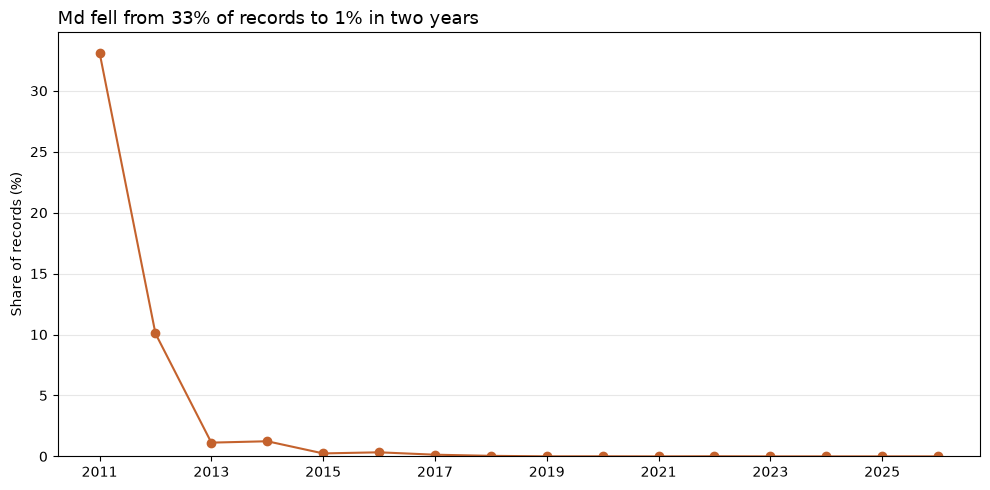

In [36]:
mag_type = df["Type"].str.upper()
year = df["Date"].str[6:10]
mask = mag_type.isin(["MD", "ML"])
scale_share = pd.crosstab(year[mask], mag_type[mask], normalize="index") * 100

ax = scale_share["MD"].plot(s
    kind="line",
    color="#C4622D",
    figsize=(10, 5),
    marker="o",
)

ax.set_title("Md fell from 33% of records to 1% in two years", loc="left", fontsize=13)
ax.set_ylabel("Share of records (%)")
ax.set_xlabel("")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../docs/magnitude_scale_transition.png", dpi=150)
plt.show()